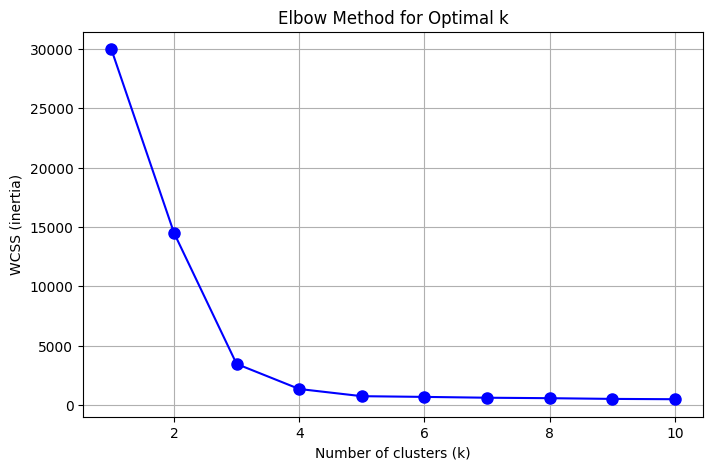

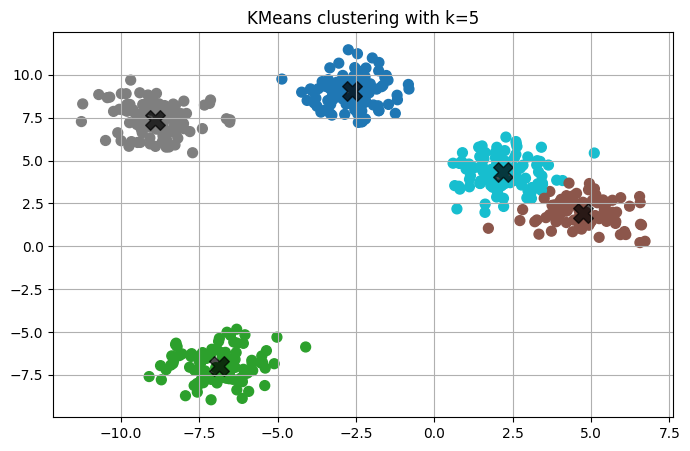

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate some synthetic data
X, y = make_blobs(
    n_samples=500,
    centers=5,    # actual number of clusters
    cluster_std=0.9,
    random_state=42
)

# 2. Compute the WCSS for different number of clusters (the elbow method)
wcss = []
K = range(1, 11)  # testing k=1 to k=10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # inertia_ is the sum of squared distances to closest cluster center

# 3. Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, wcss, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# 4. Fit final KMeans model with optimal k (e.g. choose 5 based on elbow)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
y_pred = kmeans.fit_predict(X)

# 5. Plot the clustered data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab10', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=200, alpha=0.7, marker='X')
plt.title(f'KMeans clustering with k={optimal_k}')
plt.grid(True)
plt.show()
